# Simple Linear Regression: Salary Prediction

## Problem
Predict a person's annual salary (in INR) from their years of experience.

## Objective
Understand the relationship between experience and salary, train a simple linear regression model, and measure how well it predicts salary for people it has never seen.

**Dataset:** `data/salary_data.csv` (300 rows). The data is **synthetic** (randomly generated with a fixed seed by `data/generate_data.py`) for learning purposes. It does not describe real people.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## 2. Load the Dataset

In [2]:
from pathlib import Path

def find_data(filename):
    """Find data/<filename> by searching this notebook's folder and its parent folders."""
    here = Path.cwd().resolve()
    for folder in [here, *here.parents]:
        candidate = folder / "data" / filename
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find data/{filename}. Open this notebook from inside the project folder."
    )


In [3]:
df = pd.read_csv(find_data("salary_data.csv"))
print("Shape:", df.shape)
df.head()

Shape: (300, 4)


,years_experience,education_level,skills_score,salary
0,11.6,2,79,881700
1,6.6,1,56,645400
2,12.9,2,65,886000
3,10.5,2,24,772100
4,1.4,3,43,549900


## 3. Explore the Data

In [4]:
print("Missing values:", df.isna().sum().sum())
df.describe().round(1)

Missing values: 0


,years_experience,education_level,skills_score,salary
count,300.0,300.0,300.0,300.0
mean,7.3,1.7,59.0,688547.7
std,4.4,0.7,15.4,158953.8
min,0.1,1.0,20.0,327700.0
25%,3.4,1.0,48.0,556275.0
50%,7.2,2.0,60.0,720600.0
75%,11.2,2.0,69.0,820025.0
max,14.9,3.0,100.0,974400.0


Before building a model, we plot the data. If the points roughly follow a straight line, simple linear regression is a good choice. The correlation tells us how strong the relationship is (+1 is a perfect upward line).

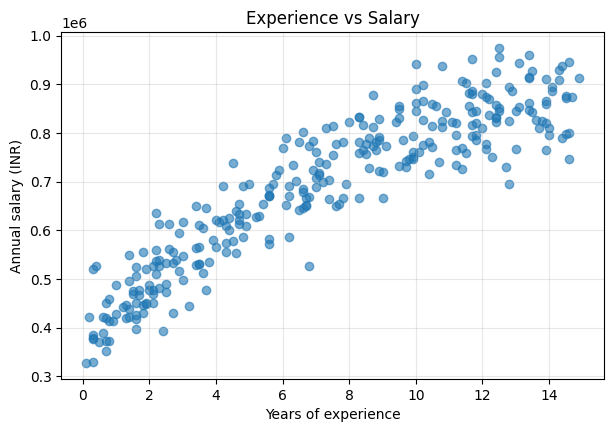

Correlation: 0.914


In [5]:
plt.figure(figsize=(7, 4.5))
plt.scatter(df["years_experience"], df["salary"], alpha=0.6)
plt.title("Experience vs Salary")
plt.xlabel("Years of experience")
plt.ylabel("Annual salary (INR)")
plt.grid(alpha=0.3)
plt.show()

print("Correlation:", round(df["years_experience"].corr(df["salary"]), 3))

## 4. Define X and y, then Split into Train and Test

- **X** (input): years of experience. It must be 2D, so we use double brackets `[["..."]]`.
- **y** (target): salary.
- We keep **80%** of the data for training and hide **20%** for testing. Testing on unseen data tells us how the model behaves in the real world.

In [6]:
X = df[["years_experience"]]
y = df["salary"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training rows:", len(X_train), "| Test rows:", len(X_test))

Training rows: 240 | Test rows: 60


## 5. Train the Model

In [7]:
model = LinearRegression()
model.fit(X_train, y_train)

print(f"Intercept   : Rs. {model.intercept_:,.0f}")
print(f"Coefficient : Rs. {model.coef_[0]:,.0f} per year of experience")

Intercept   : Rs. 444,186
Coefficient : Rs. 33,269 per year of experience


**How to read this:** the model learned a line `salary = intercept + coefficient x experience`. The **coefficient** says that each extra year of experience is linked to about **Rs. 33,000** more salary. The **intercept** is the predicted salary at zero experience.

## 6. Evaluate the Model

| Metric | Meaning |
|--------|---------|
| **R²** | Share of the salary variation the model explains (1.0 is perfect, 0 is no better than guessing the average) |
| **MAE** | Average size of the error in rupees |
| **RMSE** | Like MAE, but punishes big mistakes more |

We compare **train** and **test** scores. If the test score is much lower than the train score, the model is overfitting.

In [8]:
pred_train = model.predict(X_train)
pred_test = model.predict(X_test)

print(f"Train R2 : {r2_score(y_train, pred_train):.3f}")
print(f"Test  R2 : {r2_score(y_test, pred_test):.3f}")
print(f"Test  MAE : Rs. {mean_absolute_error(y_test, pred_test):,.0f}")
print(f"Test  RMSE: Rs. {np.sqrt(mean_squared_error(y_test, pred_test)):,.0f}")

Train R2 : 0.831
Test  R2 : 0.853
Test  MAE : Rs. 49,731
Test  RMSE: Rs. 59,476


## 7. Visualize the Fitted Line

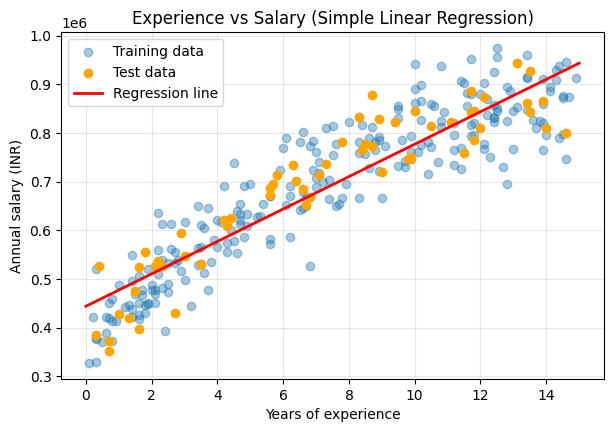

In [9]:
x_line = pd.DataFrame({"years_experience": np.linspace(0, 15, 100)})

plt.figure(figsize=(7, 4.5))
plt.scatter(X_train, y_train, alpha=0.4, label="Training data")
plt.scatter(X_test, y_test, color="orange", label="Test data")
plt.plot(x_line, model.predict(x_line), color="red", linewidth=2, label="Regression line")
plt.title("Experience vs Salary (Simple Linear Regression)")
plt.xlabel("Years of experience")
plt.ylabel("Annual salary (INR)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 8. Predict for New People

In [10]:
new_people = pd.DataFrame({"years_experience": [2, 5, 10]})
new_people["predicted_salary"] = model.predict(new_people).round(-2)
new_people

,years_experience,predicted_salary
0,2,510700.0
1,5,610500.0
2,10,776900.0


## Conclusion

- Salary and experience have a strong positive relationship (correlation about 0.91).
- On unseen test data the model reaches **R² = 0.85** with an average error of about **Rs. 49,700**.
- Train R² (0.83) and test R² (0.85) are close, so the model is **not overfitting**.
- The leftover error exists because salary also depends on other factors such as education and skills. The next notebook adds those features.
- Experience beyond the range seen in the data (0 to 15 years) should not be predicted with this model.